In [1]:
import pandas as pd
import numpy as np
import glob
import os
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
FOLDER = r"C:\Users\Dukey\Desktop\Intrusion detection with ml\MachineLearningCVE"

print("Loading all CSV files...")
all_files = glob.glob(os.path.join(FOLDER, "*.csv"))
df_list = []
for f in all_files:
    print(f"  Reading {os.path.basename(f)}...")
    df_list.append(pd.read_csv(f, low_memory=False))

df = pd.concat(df_list, ignore_index=True)
print(f"\nTotal rows loaded: {len(df):,}")

Loading all CSV files...
  Reading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
  Reading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
  Reading Friday-WorkingHours-Morning.pcap_ISCX.csv...
  Reading Monday-WorkingHours.pcap_ISCX.csv...
  Reading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
  Reading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
  Reading Tuesday-WorkingHours.pcap_ISCX.csv...
  Reading Wednesday-workingHours.pcap_ISCX.csv...

Total rows loaded: 2,830,743


In [3]:
df.columns = df.columns.str.strip()

In [4]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Dropped {before - len(df):,} rows with NaN/Infinity")
print(f"Remaining rows: {len(df):,}")

Dropped 2,867 rows with NaN/Infinity
Remaining rows: 2,827,876


In [5]:
print("\nLabel distribution:")
print(df["Label"].value_counts())



Label distribution:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [6]:
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["Label"])
print(f"\nClasses ({len(le.classes_)}):", list(le.classes_))


Classes (15): ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack � Brute Force', 'Web Attack � Sql Injection', 'Web Attack � XSS']


In [7]:
X = df.drop(["Label", "label_enc"], axis=1)

In [8]:
X = X.select_dtypes(include=[np.number])

y = df["label_enc"]


In [9]:
print("\nSplitting into train/test (80/20)...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {len(X_train):,} | Test size: {len(X_test):,}")


Splitting into train/test (80/20)...
Train size: 2,262,300 | Test size: 565,576


In [10]:
clf = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_alpha=0.1,
    reg_lambda=1.5,
    device="cuda",
    random_state=42,
    eval_metric="mlogloss",
    early_stopping_rounds=20,
    num_class=len(le.classes_)
)
clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=25
)

[0]	validation_0-mlogloss:0.61940
[25]	validation_0-mlogloss:0.14677
[50]	validation_0-mlogloss:0.05592
[75]	validation_0-mlogloss:0.02699
[100]	validation_0-mlogloss:0.01573
[125]	validation_0-mlogloss:0.01035
[150]	validation_0-mlogloss:0.00770
[175]	validation_0-mlogloss:0.00617
[200]	validation_0-mlogloss:0.00529
[225]	validation_0-mlogloss:0.00477
[250]	validation_0-mlogloss:0.00444
[275]	validation_0-mlogloss:0.00424
[300]	validation_0-mlogloss:0.00406
[325]	validation_0-mlogloss:0.00392
[350]	validation_0-mlogloss:0.00382
[375]	validation_0-mlogloss:0.00373
[400]	validation_0-mlogloss:0.00367
[425]	validation_0-mlogloss:0.00362
[450]	validation_0-mlogloss:0.00358
[475]	validation_0-mlogloss:0.00355
[499]	validation_0-mlogloss:0.00352


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,'cuda'
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'mlogloss'


c:\Users\Dukey\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:751: UserWarning: [15:47:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Accuracy: 0.9990

Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    454265
                       Bot       0.94      0.75      0.84       391
                      DDoS       1.00      1.00      1.00     25605
             DoS GoldenEye       1.00      1.00      1.00      2059
                  DoS Hulk       1.00      1.00      1.00     46025
          DoS Slowhttptest       0.99      0.99      0.99      1100
             DoS slowloris       1.00      1.00      1.00      1159
               FTP-Patator       1.00      1.00      1.00      1587
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      0.43      0.60         7
                  PortScan       0.99      1.00      1.00     31761
               SSH-Patator       1.00      1.00      1.00      1180
  Web Attack � Brute Force       0.72      0.92      0.81       301
Web A

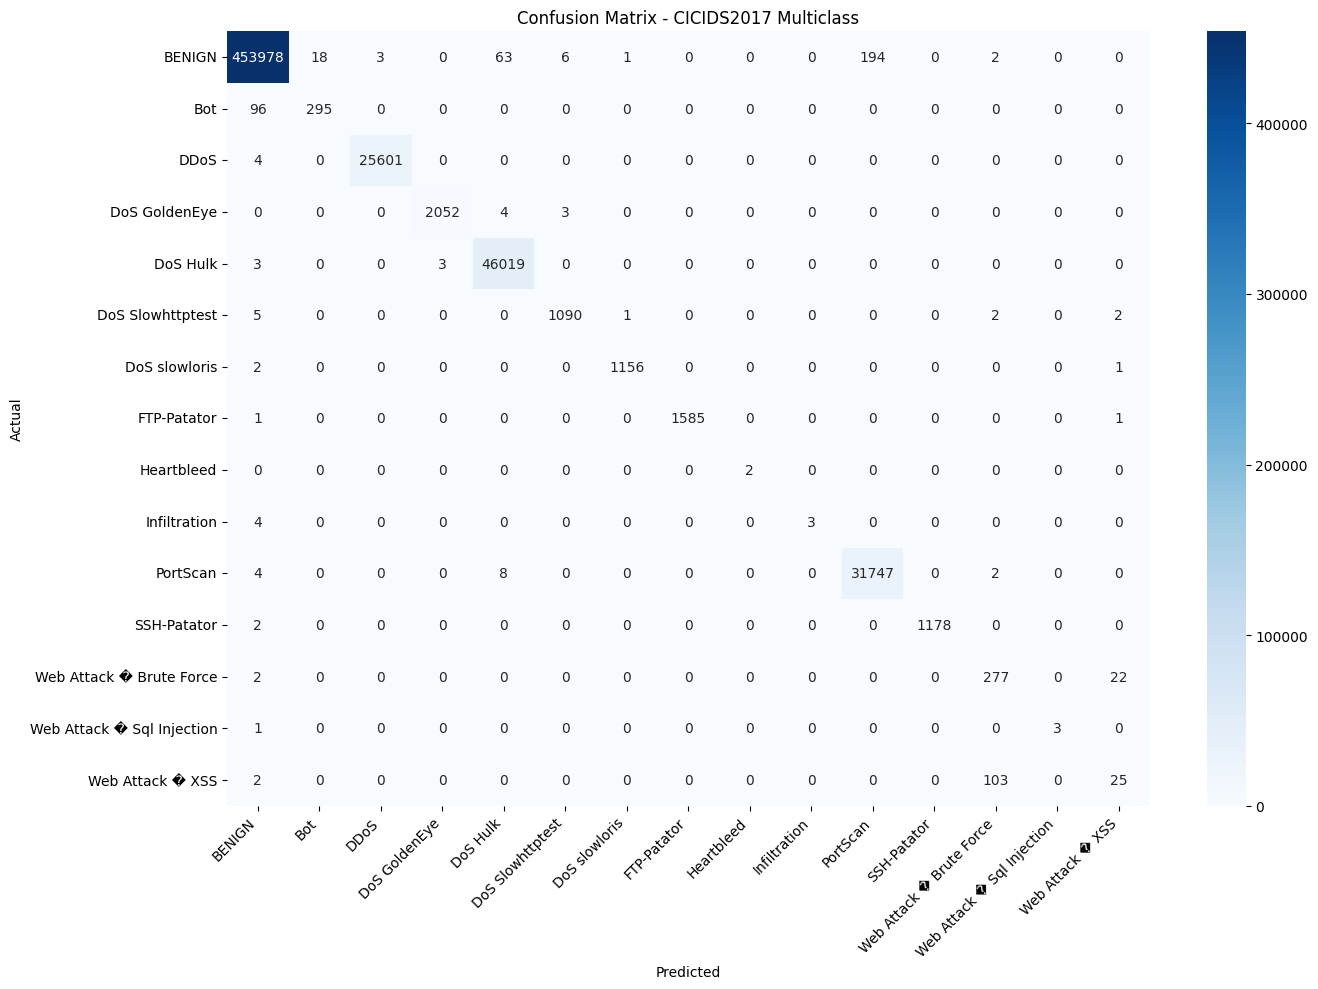

In [11]:
y_pred = clf.predict(X_test)
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix - CICIDS2017 Multiclass")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()


C:\Users\Dukey\AppData\Local\Temp\ipykernel_25892\3907714660.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")


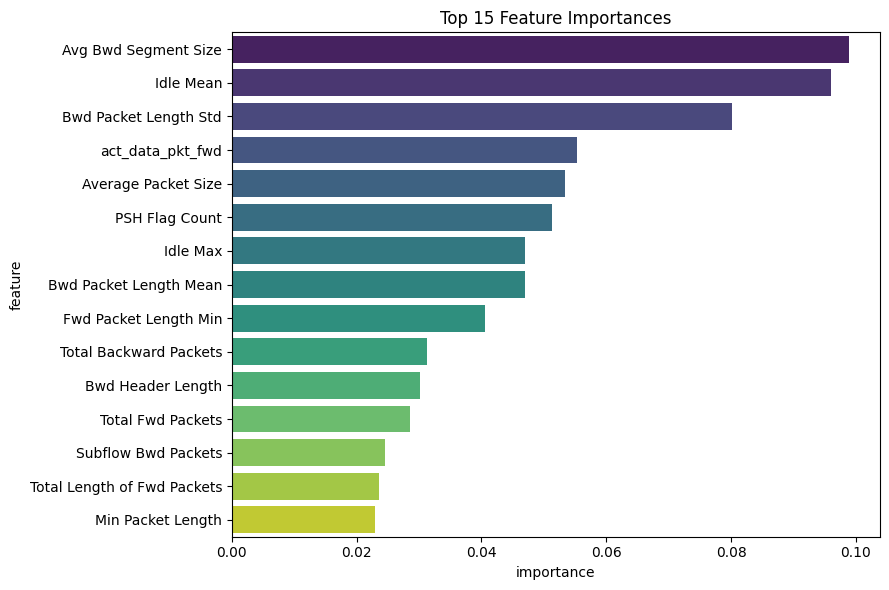

In [12]:
importances = clf.feature_importances_
feat_df = pd.DataFrame({"feature": X_train.columns, "importance": importances})
feat_df = feat_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(data=feat_df, x="importance", y="feature", palette="viridis")
plt.title("Top 15 Feature Importances")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()

In [13]:
clf.save_model("ids_model_test2.json")
print("\nModel saved as ids_model.json")
print("Plots saved as confusion_matrix.png and feature_importance.png")


Model saved as ids_model.json
Plots saved as confusion_matrix.png and feature_importance.png
